Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader

In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import os
import pyro

/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
def load_adata(data_dir = "."):
    rna_adata = ad.read_h5ad(f"{data_dir}/ann_exp.h5ad")
    rna_adata.obs['library_size']=rna_adata.X.sum(axis=1)
    rna_adata.varm['gene_tested'] = ad.read_h5ad(f"{data_dir}/ann_Element_x_tested_genes.h5ad").to_df().T
    grna_adata = ad.read_h5ad(f"{data_dir}/ann_guide.h5ad")
    grna_adata.varm['gene_targeted'] = ad.read_h5ad(f"{data_dir}/ann_Element_guide.h5ad").to_df().T
    mdata = md.MuData({'rna':rna_adata, 'grna':grna_adata})
    mdata.write_h5mu(f'{data_dir}/gasperini_pilot_highMOI.h5mu')
    return mdata

force = True
mudata_file = "gasperini_pilot_highMOI.h5mu"
data_dir = "../../../../Data/gasperini_pilot"
if mudata_file not in os.listdir(data_dir) or force:
    mdata = load_adata(data_dir)
else:
    mdata = md.read_h5mu(os.path.join(data_dir, mudata_file))

In [3]:
# subset down to only targeted genes
rna_subset = mdata['rna'][:,mdata['rna'].varm['gene_tested'].sum(axis=1).values > 0]
rna_subset =  mdata['rna'][:,['ACTB', 'AURKAIP1']]
mdata_subset = md.MuData({'rna':rna_subset, 'grna': mdata['grna']})
mdata_subset

MuData object with n_obs × n_vars = 47964 × 3117
  2 modalities
    rna:	47964 x 2
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'gene_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'gene_targeted'

In [4]:
mdata['rna'].var_names[:100]

Index(['AL627309.1', 'AL627309.5', 'AP006222.1', 'AL732372.2', 'AL669831.3',
       'MTND1P23', 'MTND2P28', 'MTCO1P12', 'AC114498.2', 'MTATP6P1',
       'AL669831.1', 'LINC01409', 'LINC01128', 'LINC00115', 'AL645608.2',
       'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15', 'AGRN', 'AL390719.1',
       'RNF223', 'C1orf159', 'TTLL10', 'SDF4', 'B3GALT6', 'C1QTNF12', 'UBE2J2',
       'ACAP3', 'PUSL1', 'INTS11', 'CPTP', 'DVL1', 'MXRA8', 'AURKAIP1',
       'CCNL2', 'MRPL20-AS1', 'MRPL20', 'AL391244.2', 'VWA1', 'ATAD3C',
       'ATAD3B', 'ATAD3A', 'SSU72', 'AL645728.1', 'FNDC10', 'AL691432.2',
       'MIB2', 'MMP23B', 'CDK11B', 'FO704657.1', 'SLC35E2B', 'CDK11A',
       'AL031282.1', 'SLC35E2A', 'NADK', 'GNB1', 'TMEM52', 'CFAP74',
       'AL391845.2', 'GABRD', 'PRKCZ', 'AL590822.2', 'FAAP20', 'SKI', 'MORN1',
       'RER1', 'PEX10', 'PANK4', 'AL139246.5', 'TNFRSF14-AS1', 'TNFRSF14',
       'PRXL2B', 'AL512383.1', 'TPRG1L', 'WRAP73', 'TP73', 'TP73-AS1',
       'CCDC27', 'SMIM1', 'LRRC47', 'CEP1

In [5]:
perturbvi.PERTURBVI.setup_mudata(
    mdata_subset,
    batch_key="bath_number",
    size_factor_key="library_size",
    modalities={
        "rna_layer": 'rna',
        "perturbation_layer": 'grna',
    },
)

model = perturbvi.PERTURBVI(mdata_subset)
model.view_anndata_setup()

Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'batch_key': 'bath_number',
│   'perturbation_layer': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'},
│   'size_factor_key': 'library_size',
│   'cat_cov_keys': None,
│   'cont_cov_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   6   │
│         n_cells          │ 47964 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│     n_perturbations      │ 3115  │
│          n_vars          │   2   │
└──────────────────────────┴───────┘

                       Data Registry                        
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Registry Key    ┃         scvi-tools Location          ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         X         │          adata.mod['rna'].X          │
│       batch       │ adata.mod['rna'].obs['_scvi_batch']  │
│       ind_x       │    adata.mod['rna'].obs['_ind_x']    │
│ observed_lib_size │ adata.mod['rna'].obs['library_size'] │
│   perturbations   │         adata.mod['grna'].X          │
└───────────────────┴──────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

In [6]:
# optimizer = pyro.optim.ClippedAdam({'lr':0.001, 'lrd':0.9})
model.train(
    max_epochs=30,
    train_size=1,
    batch_size=1024,
    lr=0.1
    # plan_kwargs={"optim": optimizer},
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 1/30:   0%|          | 0/30 [00:00<?, ?it/s]

Exception: (tensor([[4.],
        [2.],
        [0.],
        ...,
        [2.],
        [1.],
        [1.]]), torch.Size([1024, 1]))

In [ ]:
# optimizer = pyro.optim.ClippedAdam({'lr':0.001, 'lrd':0.9})
model.train(
    max_epochs=50,
    train_size=1,
    batch_size=1024,
    lr=0.001
    # plan_kwargs={"optim": optimizer},
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 30/30: 100%|██████████| 30/30 [00:21<00:00,  1.45it/s, v_num=1, elbo_train=3.4e+5] 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:21<00:00,  1.42it/s, v_num=1, elbo_train=3.4e+5]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,z_score,mean_mu,disp_mu,p_val,grna
0,-4.264263,-0.239629,0.232873,0.000010,ACTB_TSS|1
1,-2.628215,-0.147692,0.187508,0.004292,ACTB_TSS|2
504,-1.389719,-0.078095,0.079663,0.082307,PSMB6_TSS|1
530,-1.351386,-0.075941,0.085276,0.088286,RBMX_TSS|1
1988,-1.346720,-0.075678,0.074754,0.089035,chr22:23875249-23875272|2
...,...,...,...,...,...
83,1.731112,0.097279,-0.079582,0.958284,CCT5_TSS|2
559,1.755744,0.098663,-0.096033,0.960434,RPL23_TSS|2
173,1.782195,0.100150,-0.109665,0.962641,EEF2_TSS|2
896,2.591063,0.145604,-0.112307,0.995216,chr11:33966182-33966205|2


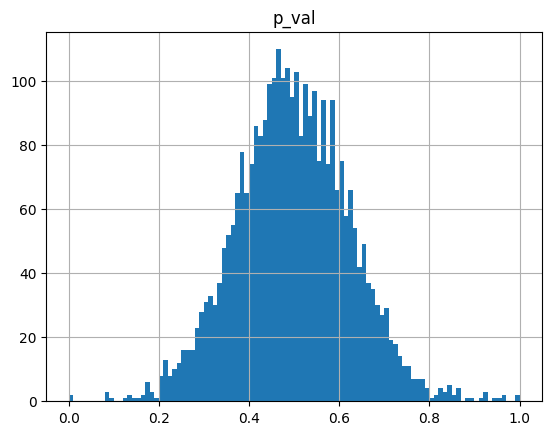

In [ ]:
%load_ext autoreload
%autoreload 2
from scipy.stats import norm

gene_index = 0

perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril'] * pyro.get_param_store()['scale_factor'].exp()
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.cdf(0, loc=-perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)
# perturb_z_scores[:,gene_index].detach().cpu().numpy()
z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
                    'mean_mu': perturb_mean_lfc_mu[:,gene_index],
                    'disp_mu': perturb_disp_lfc_mu[:,gene_index],
                    'p_val': perturb_p_vals[:,gene_index],
                    'grna': mdata_subset['grna'].var_names,})
z_df.hist('p_val', bins=100)
z_df.sort_values('p_val', ascending=True)


In [ ]:
for k, v in pyro.get_param_store().items():
    print (k, v.shape)

scale_factor torch.Size([])
log_var_mean.mu torch.Size([2])
log_var_disp.mu torch.Size([2])
log_var_mean.sigma torch.Size([2])
log_var_disp.sigma torch.Size([2])
perturb_mean_lfc.mu torch.Size([3115, 2])
perturb_disp_lfc.mu torch.Size([3115, 2])
perturb_lfc.scale_tril torch.Size([3115, 2, 2, 2])


In [ ]:
perturb_mean_lfc.mu

NameError: name 'perturb_mean_lfc' is not defined